**Import The libraries**

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [170]:
df = pd.read_csv('/content/customer_churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Here total charges are object, but the total charges should be int


In [172]:
for i in df.columns:
  print(df[i].value_counts())

customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
gender
Male      3555
Female    3488
Name: count, dtype: int64
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
OnlineSecurity
No                     3498
Yes                    2019
No internet service    15

In [173]:
(df['TotalCharges']==' ').sum()

np.int64(11)

In [174]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [175]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [176]:
df[df['tenure']==0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

We dont want those customer who's tenure is 0, so we drop them.



In [177]:
df.drop(df[df['tenure']==0].index,inplace=True)

In [178]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


We also dont need of customer id column so we drop the customer id column

In [179]:
df=df.drop('customerID',axis=1)

In [180]:
df.duplicated().sum()

np.int64(22)

In [181]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [182]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [183]:
df.describe(include='object').T

,count,unique,top,freq
gender,7032,2,Male,3549
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,3,No,3385
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,3,No,3497
OnlineBackup,7032,3,No,3087
DeviceProtection,7032,3,No,3094
TechSupport,7032,3,No,3472


### one hot encoding

In [184]:
df2 = df


In [185]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [186]:
dummy = pd.get_dummies(df2)
dummy

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,False,True,False,True,False,...,True,False,True,False,False,True,False,False,False,True
7039,0,72,103.20,7362.90,0,True,False,False,True,False,...,True,False,True,False,False,True,False,True,False,False
7040,0,11,29.60,346.45,0,True,False,False,True,False,...,False,True,False,False,False,True,False,False,True,False
7041,1,4,74.40,306.60,1,False,True,False,True,True,...,False,True,False,False,False,True,False,False,False,True


In [187]:
corr=dummy.corr()['Churn']


<Axes: >

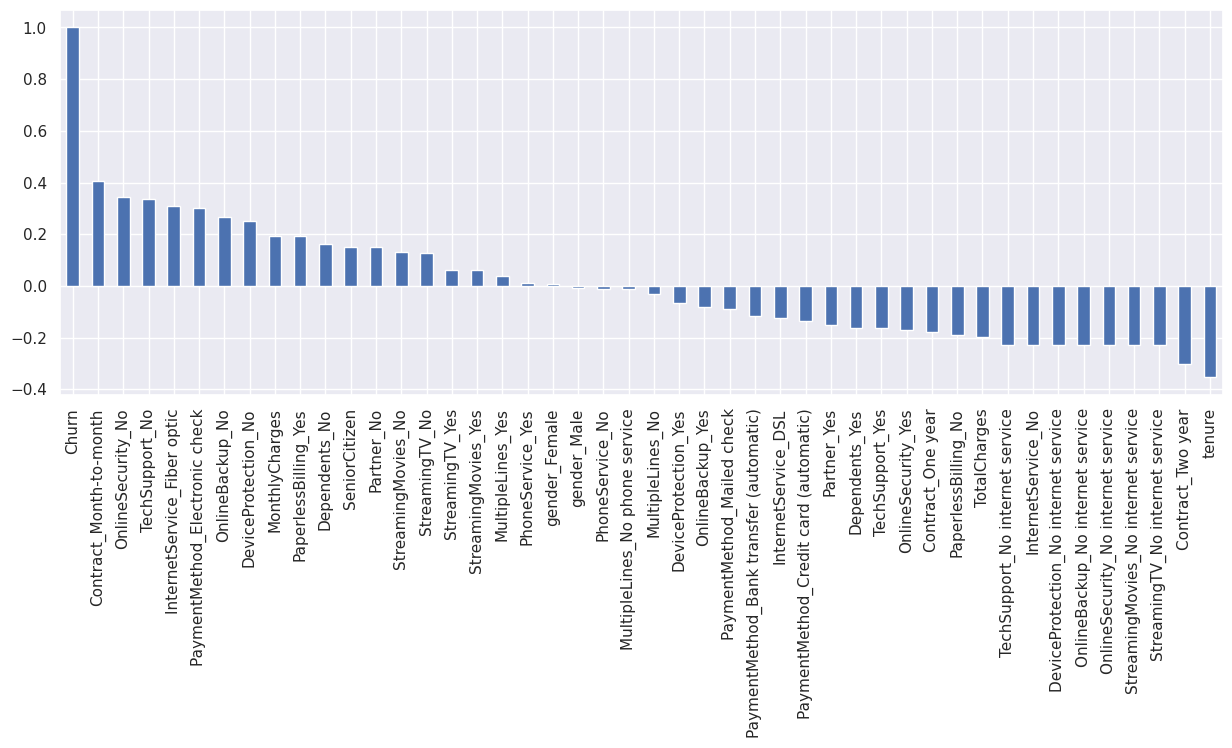

In [188]:
plt.figure(figsize=(15,5))
sns.set(style='darkgrid')
dummy.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')

In [189]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Visulaization of the data

In [190]:

fig = px.histogram(df,x='Churn',color='gender',barmode='group',title='<b>Churn distribution w.r.t Gender<b>',color_discrete_map={'Female':'pink','Male':'skyblue'})
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

In [191]:
fig = px.histogram(df,x='Churn',color='SeniorCitizen',barmode='group',title='<b>Churn distribution w.r.t SeniorCitizen<b>')
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

* 16% of the customer who are senior ctitzen are use our services.
* 6.7% of customer who are senior citizen was churn out
* 20% of the customer who are not senior citizen was churn out

In [192]:
fig = px.histogram(df,x='Churn',color='Partner',barmode='group',title='<b>Churn distribution w.r.t Partner<b>')
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

mostly Customer who dont have a partner was churn out

In [193]:
fig = px.histogram(df,x='Churn',color='Contract',barmode='group',title='<b>Churn distribution w.r.t Dependents<b>',text_auto=True)
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

* There are 56% customer who have contract with Month-to-Month
* 20% customer have One year contract with us
* 24% customer have two year contract
* 23% customer who have a month to month contract was churn out
* 2% customer churn out who have one year contract
* 0.5% customer who have two year contract was churn out

In [194]:
fig = px.histogram(df,x='Churn',color='PaymentMethod',title='<b>Churn distribution w.r.t PaymentMethod<b>',text_auto=True)
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

33% customer used electronic check as payment method
* Moatly customer who use electronic check as payment method were moved out in compare to others

In [195]:
fig = px.histogram(df,x='Churn',color='OnlineSecurity',title='<b>Churn distribution w.r.t OnlineSecurity<b>',text_auto=True)
fig.update_layout(bargap=0.2,width =700,height=500)
fig.show()

Mostly customers who have no online security were moved out

### Label Encoding

In [196]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [197]:
for x in df.columns:
  if df[x].dtype=='object':
    df[x]=le.fit_transform(df[x])

In [198]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [199]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [200]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [201]:
df.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,int64
OnlineSecurity,int64
OnlineBackup,int64


In [221]:
df.corr()[['Churn']]

,Churn
gender,-0.008545
SeniorCitizen,0.150541
Partner,-0.149982
Dependents,-0.163128
tenure,-0.354049
PhoneService,0.011691
MultipleLines,0.038043
InternetService,-0.047097
OnlineSecurity,-0.289050
OnlineBackup,-0.195290


In [257]:
fig = px.imshow(df.corr(),text_auto=True,color_continuous_scale='blues')
fig.update_layout(width =1200,height=900)
fig.update_traces(textfont_size=5)
fig.show()

In [202]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

In [203]:
x = df.drop(columns = ['PhoneService','gender','Churn'])
y = df['Churn']

In [204]:
x_res,y_res = smote.fit_resample(x,y)

In [205]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_res,y_res,test_size=0.25,random_state=7)

In [206]:
x_train

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
477,0,1,1,7,0,0,2,2,2,2,2,0,0,1,2,75.700000,554.050000
2830,1,0,0,66,2,0,2,2,0,2,0,0,1,1,1,63.850000,4174.350000
529,0,1,1,24,0,2,1,1,1,1,1,1,2,1,1,21.100000,490.650000
9220,0,0,0,2,0,1,0,0,0,0,1,0,0,1,2,79.383104,147.782810
6656,0,1,1,43,1,0,0,2,0,0,0,0,0,0,1,29.300000,1224.050000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
919,0,0,0,12,0,2,1,1,1,1,1,1,0,0,3,20.450000,255.350000
4307,1,0,0,24,2,1,0,2,0,0,2,2,0,1,2,101.250000,2440.150000
5699,1,1,1,11,2,1,0,0,2,0,0,0,0,1,1,78.100000,864.850000
537,0,1,0,69,0,1,0,2,0,0,2,2,1,1,1,95.650000,6744.200000


In [207]:
y_train

,Churn
477,0
2830,0
529,0
9220,1
6656,0
...,...
919,0
4307,1
5699,0
537,0


In [208]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [209]:
x_train

array([[-0.40170602,  1.29348758,  1.91296797, ...,  0.44570095,
         0.26991772, -0.68153639],
       [ 2.48938266, -0.77310368, -0.52274791, ..., -0.55647912,
        -0.14432531,  0.98894568],
       [-0.40170602,  1.29348758,  1.91296797, ..., -0.55647912,
        -1.63874637, -0.71079048],
       ...,
       [ 2.48938266,  1.29348758,  1.91296797, ..., -0.55647912,
         0.35381504, -0.53812678],
       [-0.40170602,  1.29348758, -0.52274791, ..., -0.55647912,
         0.96731421,  2.17472816],
       [-0.40170602, -0.77310368, -0.52274791, ...,  1.44788103,
         0.07123998, -0.90487954]])

In [210]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
lr = LogisticRegression(random_state=0)

In [211]:
model = lr.fit(x_train,y_train)

In [212]:
pred = model.predict(x_test)

In [213]:
print(accuracy_score(y_test,pred))
print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

0.7943454686289698
[[ 983  337]
 [ 194 1068]]
              precision    recall  f1-score   support

           0       0.84      0.74      0.79      1320
           1       0.76      0.85      0.80      1262

    accuracy                           0.79      2582
   macro avg       0.80      0.80      0.79      2582
weighted avg       0.80      0.79      0.79      2582



## Summary:

### Data Analysis Key Findings
*   The best Logistic Regression model,achieved an accuracy score of 0.794 on the test set.
*   The confusion matrix for the test set predictions was:
    *   True Negatives (correctly predicted class 0): 983
    *   False Positives (incorrectly predicted class 1 for actual class 0): 337
    *   False Negatives (incorrectly predicted class 0 for actual class 1): 194
    *   True Positives (correctly predicted class 1): 1068
*   The classification report revealed:
    *   For class 0, precision was 0.84, recall was 0.74, and the f1-score was 0.79.
    *   For class 1, precision was 0.76, recall was 0.85, and the f1-score was 0.80.
    *   The macro average and weighted average f1-scores were both approximately 0.80, indicating a balanced performance across classes.

### Insights or Next Steps
*   The model demonstrates reasonably good predictive power, with an overall accuracy of nearly 80%. The recall for class 1 (0.85) is notably higher than for class 0 (0.74), suggesting it is better at identifying positive cases.
*   Further investigation into the misclassified samples (false positives and false negatives) could help identify patterns or features that could be improved to enhance the model's precision for class 1 and recall for class 0.
